# LSTM Experiments & Evaluation

Notebook ini:
1. Load bobot LSTM terbaik dari tiap variasi training
2. Evaluasi BLEU-4 dan METEOR pada test set
3. Bandingkan Keras vs From Scratch inference
4. Qualitative analysis: 10 contoh gambar
5. Pengaruh max caption length

In [10]:
import os, sys, json, time, pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '../..')))

import tensorflow as tf
from tensorflow import keras

from src.lstm.train_keras import build_lstm_decoder, EMBED_DIM
from src.lstm.model import LSTMDecoder
from src.shared.caption_utils import load_vocabulary, clean_caption
from src.shared.metrics import bleu4, meteor

print('TF:', tf.__version__)

TF: 2.16.2


## 1. Load Data & Vocabulary

In [11]:
from pathlib import Path

def find_repo_root(start: Path) -> Path:
    cur = start.resolve()
    for _ in range(6):
        if (cur / 'src').exists() and (cur / 'requirements.txt').exists():
            return cur
        cur = cur.parent
    return start.resolve()

def normalize_id(x: str) -> str:
    return Path(x).stem

ROOT = find_repo_root(Path.cwd())

FEATURES_PATH = ROOT / 'features' / 'flickr8k_features.npy'
FEAT_IDX_PATH = ROOT / 'features' / 'flickr8k_idx.json'
VOCAB_PATH    = ROOT / 'features' / 'vocab.json'
CAPTIONS_TXT  = ROOT / 'data' / 'flickr8k' / 'captions.txt'
IMAGES_DIR    = ROOT / 'data' / 'flickr8k' / 'Images'
MODELS_DIR    = ROOT / 'models' / 'lstm'

missing = [p for p in (FEATURES_PATH, FEAT_IDX_PATH, VOCAB_PATH, CAPTIONS_TXT) if not p.exists()]
if missing:
    missing_list = '\n'.join(f'- {p}' for p in missing)
    raise FileNotFoundError(
        'File(s) missing:\n' + missing_list +
        "\n\nRun 05_Feature_extraction.ipynb and 06_Caption_preprocessing.ipynb to generate features/vocab."
    )

features = np.load(FEATURES_PATH)
with open(FEAT_IDX_PATH) as f:
    img_idx_raw = json.load(f)

img_idx = {normalize_id(k): int(v) for k, v in img_idx_raw.items()}
image_ids  = [img_id for img_id, _ in sorted(img_idx.items(), key=lambda x: x[1])]
vocab      = load_vocabulary(VOCAB_PATH)
VOCAB_SIZE = len(vocab)
FEATURE_DIM = features.shape[1]
idx2word   = {v: k for k, v in vocab.items()}

print(f'Features: {features.shape}, Vocab: {VOCAB_SIZE}')

captions_dict = {}
with open(CAPTIONS_TXT) as f:
    for line in f:
        line = line.strip()
        if not line or line.lower().startswith('image'):
            continue
        parts = line.split(',', 1)
        if len(parts) < 2:
            continue
        img_file, caption = parts
        img_id = normalize_id(img_file.split('#')[0].strip())
        clean  = clean_caption(caption)
        captions_dict.setdefault(img_id, []).append(clean)

common_ids = [img_id for img_id in image_ids if img_id in captions_dict]
if not common_ids:
    raise ValueError('Tidak ada image_id yang cocok antara features dan captions.')

test_ids = common_ids[7000:8000]
test_captions = {k: captions_dict.get(k, []) for k in test_ids}
print(f'Test images: {len(test_ids)}')

Features: (8091, 2048), Vocab: 7684
Test images: 1000


## 2. Fungsi Helper Evaluasi

In [12]:
MAX_LEN = 30

CONFIGS = [
    {'name': 'lstm-1layer-128', 'num_lstm_layers': 1, 'lstm_units': 128},
    {'name': 'lstm-2layer-128', 'num_lstm_layers': 2, 'lstm_units': 128},
    {'name': 'lstm-3layer-128', 'num_lstm_layers': 3, 'lstm_units': 128},
    {'name': 'lstm-1layer-512', 'num_lstm_layers': 1, 'lstm_units': 512},
    {'name': 'lstm-2layer-512', 'num_lstm_layers': 2, 'lstm_units': 512},
    {'name': 'lstm-3layer-512', 'num_lstm_layers': 3, 'lstm_units': 512},
]

def decode_keras(keras_model, feat_vec, max_len=MAX_LEN):
    start_idx = vocab.get('<start>', 1)
    end_idx   = vocab.get('<end>',   2)
    pad_idx   = vocab.get('<pad>',   0)

    token_ids = [start_idx]
    feat_in   = feat_vec[np.newaxis, :]

    for _ in range(max_len):
        cap_in  = np.array(token_ids + [pad_idx] * (max_len - 1 - len(token_ids)),
                           dtype=np.int32)[np.newaxis, :]
        logits  = keras_model.predict([feat_in, cap_in], verbose=0)
        next_id = int(np.argmax(logits[0, len(token_ids) - 1, :]))
        if next_id == end_idx or next_id == pad_idx:
            break
        token_ids.append(next_id)

    words = [idx2word.get(i, '<unk>') for i in token_ids[1:]]
    return [w for w in words if w not in ('<start>', '<end>', '<pad>', '<unk>')]

def evaluate_model(decoder, test_ids, img_idx, features,
                    test_captions, max_len=MAX_LEN, use_keras=False, keras_model=None):
    references, hypotheses = [], []

    for img_id in test_ids:
        if img_id not in img_idx:
            continue
        refs = [r.split() for r in test_captions.get(img_id, [])]
        if not refs:
            continue
        feat_vec = features[img_idx[img_id]]

        if use_keras:
            hyp = decode_keras(keras_model, feat_vec, max_len)
        else:
            hyp = decoder.generate_caption(feat_vec, max_len).split()

        references.append(refs)
        hypotheses.append(hyp)

    b4  = bleu4(references, hypotheses)
    met = meteor(references, hypotheses)
    return b4, met, references, hypotheses

## 3. Evaluasi Semua Variasi (From Scratch)

In [13]:
results = {}

for cfg in CONFIGS:
    ckpt = os.path.join(MODELS_DIR, f'{cfg["name"]}.weights.h5')
    if not os.path.exists(ckpt):
        print(f'[SKIP] {cfg["name"]} — checkpoint tidak ditemukan')
        continue

    keras_model = build_lstm_decoder(
        vocab_size=VOCAB_SIZE,
        feature_dim=FEATURE_DIM,
        embed_dim=EMBED_DIM,
        lstm_units=cfg['lstm_units'],
        num_lstm_layers=cfg['num_lstm_layers'],
        max_len=MAX_LEN - 1,
    )
    keras_model.load_weights(ckpt)

    scratch_decoder = LSTMDecoder()
    scratch_decoder.load_weights(keras_model, vocab)

    t0 = time.time()
    b4, met, refs, hyps = evaluate_model(
        scratch_decoder, test_ids, img_idx, features, test_captions, MAX_LEN
    )
    t_scratch = time.time() - t0

    results[cfg['name']] = {
        'bleu4': b4, 'meteor': met,
        'time_scratch': t_scratch,
        'refs': refs, 'hyps': hyps,
    }
    print(f'  BLEU-4: {b4:.4f} | METEOR: {met:.4f} | Time: {t_scratch:.1f}s')

if not results:
    raise ValueError('Tidak ada model yang berhasil dievaluasi. Pastikan weights ada di models/lstm/.')

os.makedirs(MODELS_DIR, exist_ok=True)
with open(os.path.join(MODELS_DIR, 'lstm_eval_results.pkl'), 'wb') as f:
    pickle.dump(results, f)
print('Results saved.')

2026-05-15 16:53:32.418529: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-05-15 16:53:32.418643: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-05-15 16:53:32.418656: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-05-15 16:53:32.418828: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-15 16:53:32.418845: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
/Users/ziyanagil/Agil/Semester 08/IF3270 Pembelajaran Mesin/Tubes 2/CNN-RNN-digaspolndangakndangak/src/lstm/layers/activations.py:8: RuntimeWarning: overflow encountered in exp
  return 

  BLEU-4: 0.1192 | METEOR: 0.3256 | Time: 7.2s
  BLEU-4: 0.1377 | METEOR: 0.3414 | Time: 7.1s
  BLEU-4: 0.1173 | METEOR: 0.3226 | Time: 8.0s
  BLEU-4: 0.1474 | METEOR: 0.3657 | Time: 19.6s
  BLEU-4: 0.1523 | METEOR: 0.3584 | Time: 34.8s
  BLEU-4: 0.1345 | METEOR: 0.3479 | Time: 28.4s
Results saved.


## 4. Perbandingan Keras vs From Scratch (Best Model)

In [14]:
best_name = max(results, key=lambda k: results[k]['bleu4'])
best_cfg  = next(c for c in CONFIGS if c['name'] == best_name)
print(f'Model terbaik: {best_name} (BLEU-4: {results[best_name]["bleu4"]:.4f})')

keras_model = build_lstm_decoder(
    vocab_size=VOCAB_SIZE, feature_dim=FEATURE_DIM, embed_dim=EMBED_DIM,
    lstm_units=best_cfg['lstm_units'], num_lstm_layers=best_cfg['num_lstm_layers'],
    max_len=MAX_LEN - 1,
)
keras_model.load_weights(os.path.join(MODELS_DIR, f'{best_name}.weights.h5'))

t0 = time.time()
b4_keras, met_keras, _, _ = evaluate_model(
    None, test_ids[:100], img_idx, features, test_captions, MAX_LEN,
    use_keras=True, keras_model=keras_model,
)
t_keras = time.time() - t0

scratch_best = LSTMDecoder()
scratch_best.load_weights(keras_model, vocab)
t0 = time.time()
b4_scratch, met_scratch, _, _ = evaluate_model(
    scratch_best, test_ids[:100], img_idx, features, test_captions, MAX_LEN
)
t_scratch = time.time() - t0

print(f'\nKeras  — BLEU-4: {b4_keras:.4f}, METEOR: {met_keras:.4f}, Time: {t_keras:.1f}s')
print(f'Scratch — BLEU-4: {b4_scratch:.4f}, METEOR: {met_scratch:.4f}, Time: {t_scratch:.1f}s')

Model terbaik: lstm-2layer-512 (BLEU-4: 0.1523)


2026-05-15 16:55:19.229642: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.



Keras  — BLEU-4: 0.1438, METEOR: 0.3237, Time: 34.1s
Scratch — BLEU-4: 0.1438, METEOR: 0.3237, Time: 2.0s


## 5. Tabel Perbandingan Semua Variasi

In [15]:
print(f'{"Variasi":<22} {"Layers":<8} {"Units":<8} {"BLEU-4":<10} {"METEOR":<10} {"Time(s)":<10}')
print('-' * 70)
for cfg in CONFIGS:
    name = cfg['name']
    if name not in results:
        continue
    r = results[name]
    print(f'{name:<22} {cfg["num_lstm_layers"]:<8} {cfg["lstm_units"]:<8}'
          f' {r["bleu4"]:<10.4f} {r["meteor"]:<10.4f} {r["time_scratch"]:<10.1f}')

Variasi                Layers   Units    BLEU-4     METEOR     Time(s)   
----------------------------------------------------------------------
lstm-1layer-128        1        128      0.1192     0.3256     7.2       
lstm-2layer-128        2        128      0.1377     0.3414     7.1       
lstm-3layer-128        3        128      0.1173     0.3226     8.0       
lstm-1layer-512        1        512      0.1474     0.3657     19.6      
lstm-2layer-512        2        512      0.1523     0.3584     34.8      
lstm-3layer-512        3        512      0.1345     0.3479     28.4      


## 6. Plot BLEU-4 per Variasi

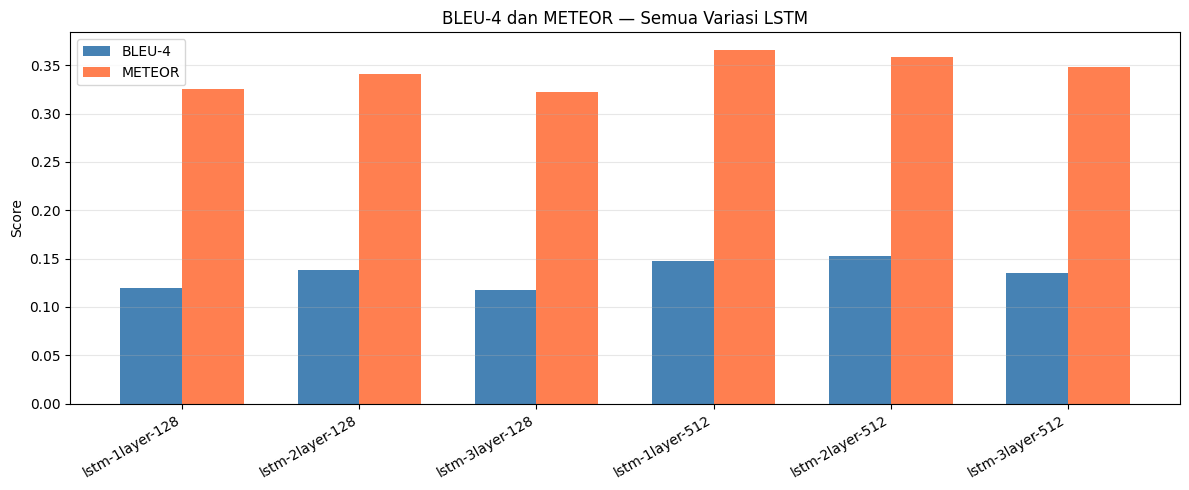

In [16]:
names  = [cfg['name'] for cfg in CONFIGS if cfg['name'] in results]
bleus  = [results[n]['bleu4']  for n in names]
meteors= [results[n]['meteor'] for n in names]

x = np.arange(len(names))
width = 0.35
fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width/2, bleus,   width, label='BLEU-4',  color='steelblue')
bars2 = ax.bar(x + width/2, meteors, width, label='METEOR',  color='coral')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=30, ha='right')
ax.set_ylabel('Score')
ax.set_title('BLEU-4 dan METEOR — Semua Variasi LSTM')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../../models/lstm/eval_scores.png', dpi=150, bbox_inches='tight')
plt.show()

## 6b. Perbandingan Jumlah Layer (LSTM)

Perbandingan BLEU-4 untuk jumlah layer 1, 2, 3 pada unit 128 dan 512.

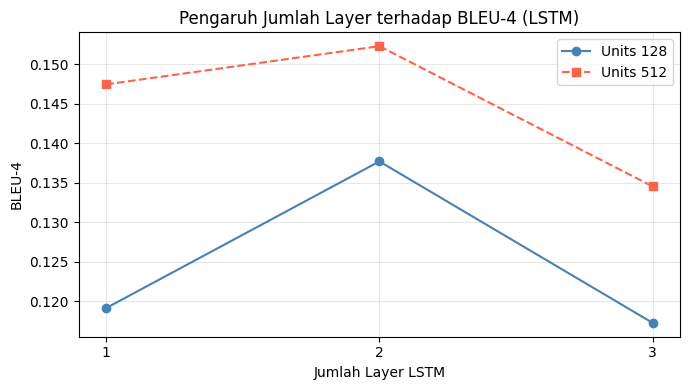

In [17]:
if 'results' not in globals():
    with open(os.path.join(MODELS_DIR, 'lstm_eval_results.pkl'), 'rb') as f:
        results = pickle.load(f)

layer_counts = [1, 2, 3]
bleu_128 = [results[f'lstm-{l}layer-128']['bleu4'] for l in layer_counts]
bleu_512 = [results[f'lstm-{l}layer-512']['bleu4'] for l in layer_counts]

plt.figure(figsize=(7, 4))
plt.plot(layer_counts, bleu_128, 'o-', label='Units 128', color='steelblue')
plt.plot(layer_counts, bleu_512, 's--', label='Units 512', color='tomato')
plt.xlabel('Jumlah Layer LSTM')
plt.ylabel('BLEU-4')
plt.title('Pengaruh Jumlah Layer terhadap BLEU-4 (LSTM)')
plt.xticks(layer_counts)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('../../models/lstm/bleu4_vs_layers.png', dpi=150)
plt.show()

## 6c. Perbandingan Ukuran Hidden State (LSTM)

Perbandingan BLEU-4 untuk hidden state 128 vs 512 pada 1 dan 2 layer.

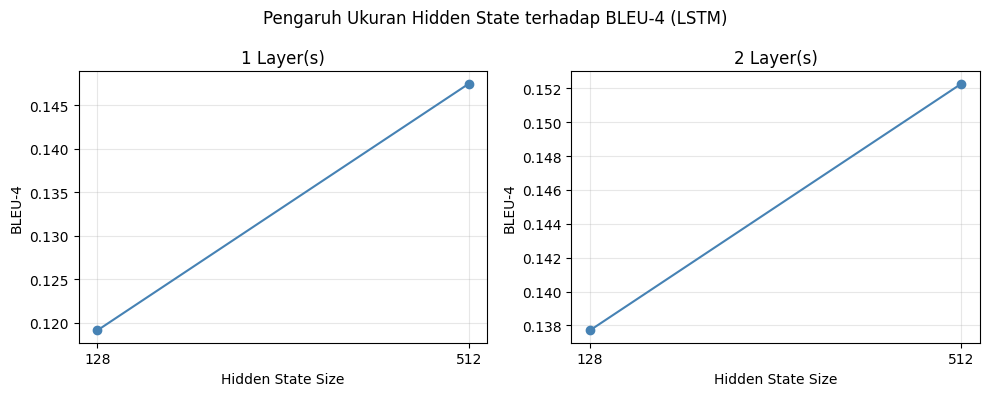

In [18]:
if 'results' not in globals():
    with open(os.path.join(MODELS_DIR, 'lstm_eval_results.pkl'), 'rb') as f:
        results = pickle.load(f)

unit_sizes = [128, 512]
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, n_layers in zip(axes, [1, 2]):
    bleu_vals = [results[f'lstm-{n_layers}layer-{u}']['bleu4'] for u in unit_sizes]
    ax.plot(unit_sizes, bleu_vals, 'o-', color='steelblue')
    ax.set_title(f'{n_layers} Layer(s)')
    ax.set_xlabel('Hidden State Size')
    ax.set_ylabel('BLEU-4')
    ax.set_xticks(unit_sizes)
    ax.grid(True, alpha=0.3)

plt.suptitle('Pengaruh Ukuran Hidden State terhadap BLEU-4 (LSTM)', fontsize=12)
plt.tight_layout()
plt.savefig('../../models/lstm/bleu4_vs_units.png', dpi=150)
plt.show()

## 7. Qualitative Analysis — 10 Contoh Gambar

Pilih gambar dengan skor tinggi, sedang, dan rendah.

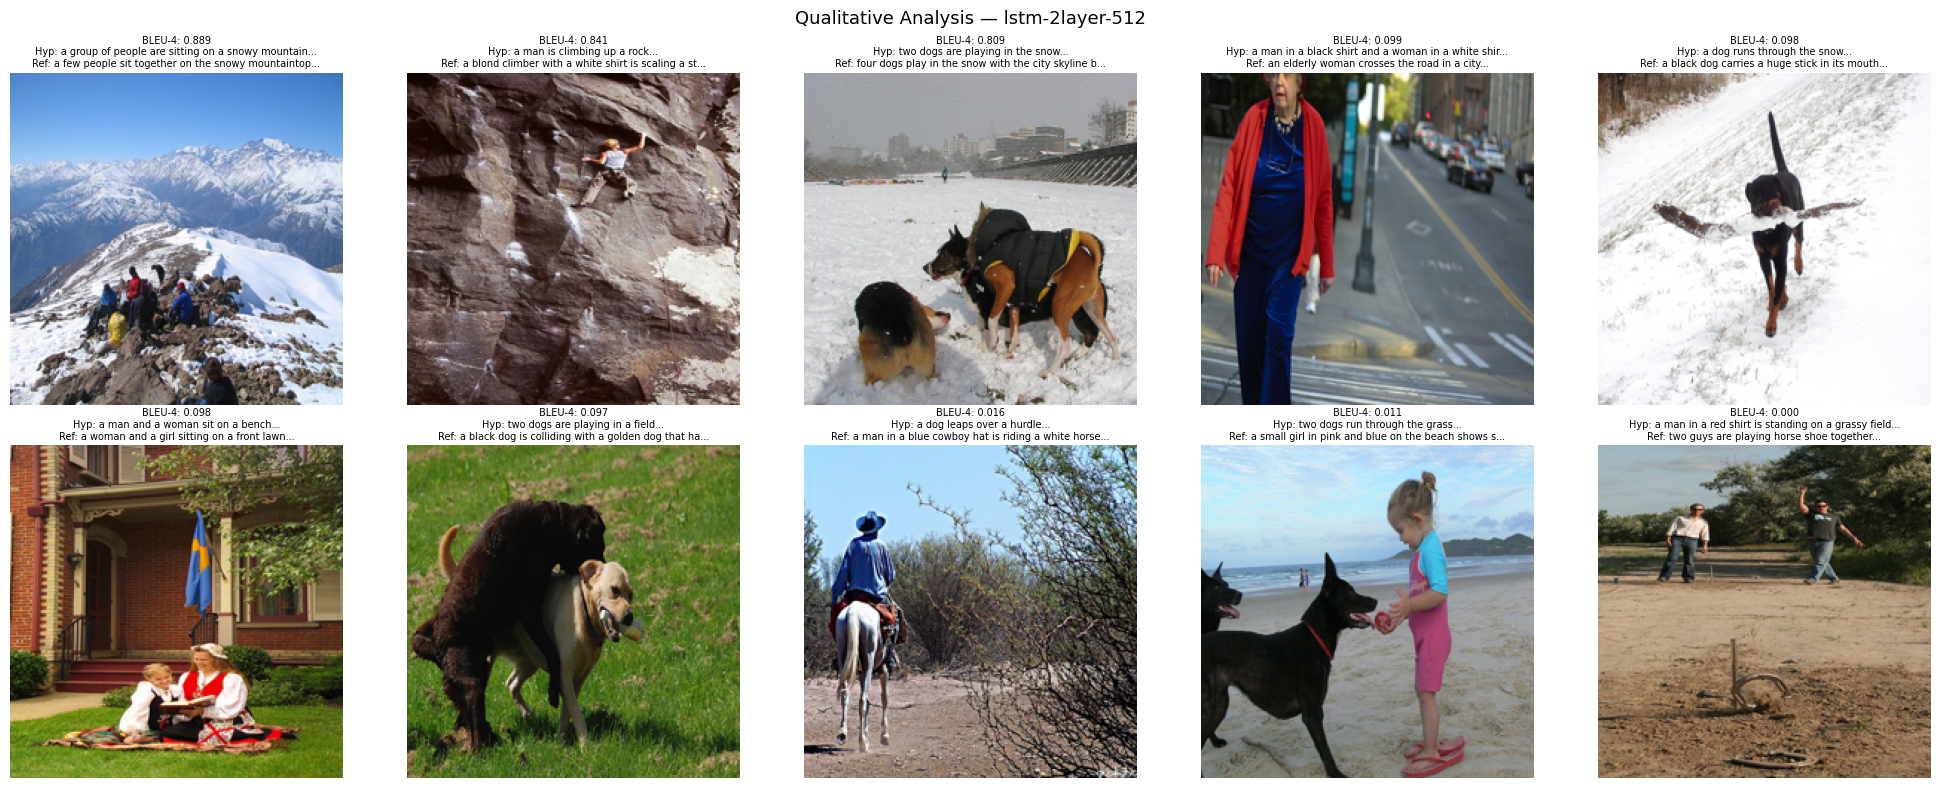

In [19]:
import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from pathlib import Path

smoothie = SmoothingFunction().method4

def resolve_image_path(images_dir, img_id: str):
    images_dir = Path(images_dir)
    candidate = images_dir / img_id
    if candidate.exists():
        return candidate
    for ext in ('.jpg', '.jpeg', '.png', '.bmp'):
        candidate = images_dir / f"{img_id}{ext}"
        if candidate.exists():
            return candidate
    matches = list(images_dir.glob(f"{img_id}.*"))
    return matches[0] if matches else None

best_refs = results[best_name]['refs']
best_hyps = results[best_name]['hyps']
valid_test_ids = [img_id for img_id in test_ids if img_id in img_idx
                  and test_captions.get(img_id)]

per_img_bleu = []
for i, (refs, hyp) in enumerate(zip(best_refs, best_hyps)):
    score = sentence_bleu(refs, hyp, weights=(0.25,)*4, smoothing_function=smoothie)
    per_img_bleu.append((score, i))

per_img_bleu.sort(key=lambda x: x[0], reverse=True)

n = len(per_img_bleu)
selected_indices = (
    [per_img_bleu[i][1] for i in range(min(3, n))] +
    [per_img_bleu[i][1] for i in range(n//2 - 2, n//2 + 2)] +
    [per_img_bleu[i][1] for i in range(max(n-3, 0), n)]
)[:10]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for ax, idx in zip(axes, selected_indices):
    img_id  = valid_test_ids[idx]
    score   = per_img_bleu[0][0] if idx == per_img_bleu[0][1] else next(
        s for s, i in per_img_bleu if i == idx
    )
    hyp_str = ' '.join(best_hyps[idx])
    ref_str = ' '.join(best_refs[idx][0])

    img_path = resolve_image_path(IMAGES_DIR, img_id)
    if img_path and img_path.exists():
        img = Image.open(img_path).resize((224, 224))
        ax.imshow(img)
    ax.axis('off')
    ax.set_title(
        f'BLEU-4: {score:.3f}\nHyp: {hyp_str[:50]}...\nRef: {ref_str[:50]}...',
        fontsize=7, wrap=True
    )

plt.suptitle(f'Qualitative Analysis — {best_name}', fontsize=13)
plt.tight_layout()
plt.savefig('../../models/lstm/qualitative.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Pengaruh Max Caption Length

Minimal 3 variasi panjang caption.

/Users/ziyanagil/Agil/Semester 08/IF3270 Pembelajaran Mesin/Tubes 2/CNN-RNN-digaspolndangakndangak/src/lstm/layers/activations.py:8: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))


max_len= 10 → BLEU-4: 0.1652
max_len= 20 → BLEU-4: 0.1569
max_len= 30 → BLEU-4: 0.1565
max_len= 40 → BLEU-4: 0.1565


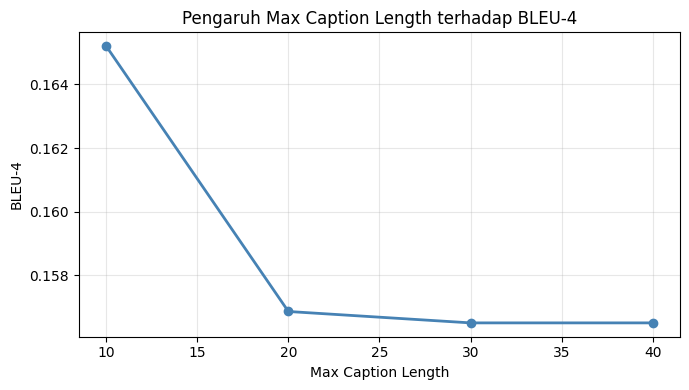

In [20]:
MAX_LEN_VARIANTS = [10, 20, 30, 40]
len_results = {}

for max_l in MAX_LEN_VARIANTS:
    b4_l, _, _, _ = evaluate_model(
        scratch_best, test_ids[:200], img_idx, features, test_captions, max_l
    )
    len_results[max_l] = b4_l
    print(f'max_len={max_l:3d} → BLEU-4: {b4_l:.4f}')

plt.figure(figsize=(7, 4))
plt.plot(list(len_results.keys()), list(len_results.values()),
         marker='o', color='steelblue', linewidth=2)
plt.xlabel('Max Caption Length')
plt.ylabel('BLEU-4')
plt.title('Pengaruh Max Caption Length terhadap BLEU-4')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../../models/lstm/max_len_effect.png', dpi=150)
plt.show()

## 9. Batch Inference Demo

In [21]:
test_sample_ids = test_ids[:5]
test_feats = np.stack([features[img_idx[i]] for i in test_sample_ids
                        if i in img_idx])

single_caps = [scratch_best.generate_caption(test_feats[i]) for i in range(len(test_feats))]

batch_caps  = scratch_best.generate_captions_batch(test_feats, batch_size=16)

print('Single vs Batch inference:')
for i, (s, b) in enumerate(zip(single_caps, batch_caps)):
    match = 'OK' if s == b else 'MISMATCH'
    print(f'  [{match}] {s[:60]}')

N_BENCH = 100
bench_feats = np.stack([features[img_idx[i]] for i in test_ids[:N_BENCH]
                          if i in img_idx])

t0 = time.time()
for fv in bench_feats:
    scratch_best.generate_caption(fv)
t_single = time.time() - t0

t0 = time.time()
scratch_best.generate_captions_batch(bench_feats, batch_size=16)
t_batch = time.time() - t0

print(f'\nSingle loop ({N_BENCH} gambar): {t_single:.2f}s')
print(f'Batch inference ({N_BENCH} gambar, batch_size=16): {t_batch:.2f}s')
print(f'Speedup: {t_single/t_batch:.2f}x')

Single vs Batch inference:
  [OK] a group of men in a field
  [OK] a group of people are standing together and smiling
  [OK] a brown dog is running through a field of grass
  [OK] a dog jumps over a barrier
  [OK] a boy in a red shirt is jumping in the air

Single loop (100 gambar): 4.06s
Batch inference (100 gambar, batch_size=16): 1.19s
Speedup: 3.42x
